# Experiments
This file contains multiple experiments that were done in order to find the solution to the [task](../task.md). Most of the necesary code is located in [piatek_Biegacz_Cieslik.py](piatek_Biegacz_Cieslik.py).

### Setup and environment check

In [ ]:
# %pip install numpy
# %pip install torch
# %pip install torchvision
# %pip install pytorch-fid

In [89]:
from pytorch_fid import fid_score
import os, sys, subprocess, shutil
import numpy as np, pandas as pd
import torch, torchvision
from torch.utils.data import Subset
from piatek_Biegacz_Cieslik import (
    VAEConfig, 
    VAEExperiment, 
    read_train_dataset, 
    create_data_loader, 
    denormalize_images
)

# Configuration & Environment
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
FLAT_REFERENCE_DIR = "temp_reference_flat"

### FID Evaluation

In [ ]:
from pytorch_fid import fid_score

def compute_fid(generated_images, reference_dir):
    """
    Saves generated samples as PNG files, then uses pytorch_fid Python API to compute FID.
    Uses num_workers=0 to avoid multiprocessing issues on Windows.
    """
    temp_gen_dir = "temp_generated_samples"
    if os.path.exists(temp_gen_dir):
        shutil.rmtree(temp_gen_dir)
    os.makedirs(temp_gen_dir)
    
    for i in range(len(generated_images)):
        torchvision.utils.save_image(generated_images[i], os.path.join(temp_gen_dir, f"{i:04d}.png"))
    
    try:
        fid_value = fid_score.calculate_fid_given_paths(
            [temp_gen_dir, reference_dir],
            batch_size=64,
            device=DEVICE,
            dims=2048,
            num_workers=0  
        )
    except Exception as e:
        print(f"FID computation failed: {e}")
        fid_value = 1000.0
    finally:
        shutil.rmtree(temp_gen_dir)
    
    return fid_value

def run_and_evaluate_configuration(experiment_name, config, training_set):
    """
    Handles the full pipeline for a single experiment: training, generation, and FID scoring.
    """
    subset_indices = np.random.choice(len(training_set), size=int(0.8 * len(training_set)), replace=False)
    data_loader = create_data_loader(Subset(training_set, subset_indices), config)
    
    vae_experiment = VAEExperiment(config)
    vae_experiment.fit(data_loader, print_progress=False)
    
    generated_samples = denormalize_images(vae_experiment.generate_samples(1000), config)
    fid_score = compute_fid(generated_samples, FLAT_REFERENCE_DIR)
    
    result = {"name": experiment_name, "fid": fid_score}
    result.update({k: v for k, v in config.__dict__.items() if k != 'train_data_path'})
    return result

def display_results(results, title="Experiment Results"):
    """Renders a styled DataFrame in the notebook with FID color gradient."""
    cols = ["name", "fid", "latent_dimension", "encoder_channels", "batch_size", "learning_rate", "kl_weight", "epochs"]
    df = pd.DataFrame(results).sort_values("fid").reset_index(drop=True)
    df = df[[c for c in cols if c in df.columns]]
    styled = (
        df.style
        .background_gradient(subset=["fid"], cmap="RdYlGn_r")
        .format({"fid": "{:.2f}", "learning_rate": "{:.1e}", "kl_weight": "{:.2f}"})
        .set_caption(title)
        .set_properties(**{"text-align": "center"})
        .set_table_styles([{"selector": "caption", "props": [("font-size", "15px"), ("font-weight", "bold"), ("padding", "8px")]}])
        .highlight_min(subset=["fid"], props="font-weight: bold; border: 2px solid #2ecc71;")
    )
    display(styled)

Load data and prepare a flattened directory for pytorch-fid (required for nested datasets)


In [91]:
base_config = VAEConfig()
_, train_dataset = read_train_dataset(base_config)

print(f"Searching for images in: {base_config.train_data_path}")

if not os.path.exists(FLAT_REFERENCE_DIR) or not os.listdir(FLAT_REFERENCE_DIR):
    if not os.path.exists(FLAT_REFERENCE_DIR):
        os.makedirs(FLAT_REFERENCE_DIR)
    
    print("Creating flat reference view (this may take a moment)...")
    count = 0
    image_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.ppm', '.webp', '.tiff')
    
    for root, _, files in os.walk(base_config.train_data_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                source = os.path.abspath(os.path.join(root, file))
                target = os.path.join(FLAT_REFERENCE_DIR, f"ref_{count:06d}_{file}")
                try:
                    os.symlink(source, target)
                except OSError:
                    # Fallback for Windows without developer mode
                    shutil.copy(source, target)
                count += 1
                
print(f"Reference ready with {len(os.listdir(FLAT_REFERENCE_DIR))} images.")

Searching for images in: c:\Users\hanna\OneDrive\PROGRAMOWANIE\Python\SSNE\mini_project_4\train\trafic_32
Reference ready with 39209 images.


### Experiments

##### Latent Space Dimensionality

This experiment checks how the latent space size affects sample quality, because too small a latent space can limit diversity while too large one may not improve FID.


In [92]:
all_experiment_results0 = []

for dim in [32, 64, 128, 256, 512]:
    config = VAEConfig(latent_dimension=dim, epochs=1)
    all_experiment_results0.append(run_and_evaluate_configuration(f"Latent_{dim}", config, train_dataset))
display_results(all_experiment_results0, "Latent Space Dimensionality")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:32<00:00,  6.66it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,Latent_512,262.01,512,"[32, 64, 128]",128,1.0e-03,0.10,1
1,Latent_128,272.81,128,"[32, 64, 128]",128,1.0e-03,0.10,1
2,Latent_64,279.01,64,"[32, 64, 128]",128,1.0e-03,0.10,1
3,Latent_256,280.82,256,"[32, 64, 128]",128,1.0e-03,0.10,1
4,Latent_32,336.76,32,"[32, 64, 128]",128,1.0e-03,0.10,1


In the quick test, I compare smaller latent spaces with only one epoch to see which size learns the basic structure fastest.


The best quick-test result was with 512 latent dimensions, so a very small latent space was not enough for good generation.


This second latent-space run uses longer training to check whether a larger bottleneck still helps after the model has time to converge.


In [93]:
all_experiment_results = []

for dim in [256, 512, 1024, 2048]:
    config = VAEConfig(latent_dimension=dim, epochs=60, kl_weight=0.01)
    all_experiment_results.append(run_and_evaluate_configuration(f"Latent_{dim}", config, train_dataset))
display_results(all_experiment_results, "Latent Space Dimensionality")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:35<00:00,  6.40it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,Latent_512,173.39,512,"[32, 64, 128]",128,1.0e-03,0.01,60
1,Latent_2048,173.78,2048,"[32, 64, 128]",128,1.0e-03,0.01,60
2,Latent_1024,176.37,1024,"[32, 64, 128]",128,1.0e-03,0.01,60
3,Latent_256,178.77,256,"[32, 64, 128]",128,1.0e-03,0.01,60


After full training, 512 and 2048 dimensions were the strongest choices, so a medium or large latent space was sufficient.


##### KL Weight


This experiment changes the KL weight to check how strongly regularization should push the posterior toward the prior.


In [94]:
kl_results = []
for kl in [0.005, 0.01, 0.1, 0.5]:
    config = VAEConfig(kl_weight=kl, latent_dimension=1024, epochs=60, batch_size=32, encoder_channels=[16, 32, 64])
    kl_results.append(run_and_evaluate_configuration(f"KL: {kl}", config, train_dataset))

all_experiment_results.append(kl_results)
display_results(kl_results, "+ KL")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:31<00:00,  6.69it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,KL: 0.01,185.05,1024,"[16, 32, 64]",32,1.0e-03,0.01,60
1,KL: 0.005,188.32,1024,"[16, 32, 64]",32,1.0e-03,0.01,60
2,KL: 0.1,201.87,1024,"[16, 32, 64]",32,1.0e-03,0.10,60
3,KL: 0.5,221.37,1024,"[16, 32, 64]",32,1.0e-03,0.50,60


A small KL weight worked best here, while stronger KL regularization made the samples worse and less sharp.


##### Network Depth and Capacity

This experiment tests encoder depth and channel width to see whether a bigger network improves image quality or just adds unnecessary complexity.


In [95]:
architectures = {
    "64_128":     [64, 128],          
    "128_256":    [128, 256],         
    "64_128_256":  [64, 128, 256],     
    "32_64_128_256":     [32, 64, 128, 256],     
    "16_32_64":      [16, 32, 64],        
    "16_32_64_128":        [16, 32, 64, 128],        
    "64_64_128":    [64, 64, 128],       
    "128_128":           [128, 128]
    }

architecture_results = []

for name, channels in architectures.items():
    config = VAEConfig(encoder_channels=channels, epochs=60, latent_dimension=1024, kl_weight=0.01, batch_size=32)
    architecture_results.append(run_and_evaluate_configuration(f"Arch_{name}", config, train_dataset))

all_experiment_results.append(architecture_results)
display_results(architecture_results, "+ Architecture")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:35<00:00,  6.39it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,Arch_16_32_64,177.82,1024,"[16, 32, 64]",32,1.0e-03,0.01,60
1,Arch_64_128_256,179.69,1024,"[64, 128, 256]",32,1.0e-03,0.01,60
2,Arch_64_128,198.27,1024,"[64, 128]",32,1.0e-03,0.01,60
3,Arch_128_256,211.23,1024,"[128, 256]",32,1.0e-03,0.01,60
4,Arch_128_128,212.49,1024,"[128, 128]",32,1.0e-03,0.01,60
5,Arch_32_64_128_256,476.15,1024,"[32, 64, 128, 256]",32,1.0e-03,0.01,60
6,Arch_16_32_64_128,476.15,1024,"[16, 32, 64, 128]",32,1.0e-03,0.01,60
7,Arch_64_64_128,476.15,1024,"[64, 64, 128]",32,1.0e-03,0.01,60


The compact encoder [16, 32, 64] gave the best FID, so the larger variants did not bring a useful gain.


##### Basic Hyperparameters

This experiment compares batch size and learning rate to check which training setup gives the most stable and useful convergence.


In [96]:
hyperparameters_experiments = []
hyperparameter_configs = [
    ("Batch32_LR1e-3", VAEConfig(batch_size=32, learning_rate=1e-3, epochs=60, latent_dimension=1024, kl_weight=0.01, encoder_channels=[16, 32, 64],)),
    ("Batch64_LR1e-3", VAEConfig(batch_size=64, learning_rate=1e-3, epochs=60, latent_dimension=1024, kl_weight=0.01, encoder_channels=[16, 32, 64],)),
    ("Batch128_LR1e-3", VAEConfig(batch_size=128, learning_rate=1e-3, epochs=60, latent_dimension=1024, kl_weight=0.01, encoder_channels=[16, 32, 64],)),
    ("Batch64_LR3e-4", VAEConfig(batch_size=64, learning_rate=3e-4, epochs=60, latent_dimension=1024, kl_weight=0.01, encoder_channels=[16, 32, 64],)),
    ("Batch32_LR3e-4", VAEConfig(batch_size=32, learning_rate=3e-4, epochs=60, latent_dimension=1024, kl_weight=0.01, encoder_channels=[16, 32, 64],)),
]
for name, config in hyperparameter_configs:
    hyperparameters_experiments.append(run_and_evaluate_configuration(name, config, train_dataset))

all_experiment_results.append(hyperparameters_experiments)
display_results(hyperparameters_experiments, "+ Hyperparameters")


100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:32<00:00,  6.66it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,Batch128_LR1e-3,171.33,1024,"[16, 32, 64]",128,1.0e-03,0.01,60
1,Batch64_LR1e-3,172.31,1024,"[16, 32, 64]",64,1.0e-03,0.01,60
2,Batch32_LR1e-3,178.43,1024,"[16, 32, 64]",32,1.0e-03,0.01,60
3,Batch32_LR3e-4,189.93,1024,"[16, 32, 64]",32,3.0e-04,0.01,60
4,Batch64_LR3e-4,205.83,1024,"[16, 32, 64]",64,3.0e-04,0.01,60


Batch size 128 with learning rate 1e-3 was the best tested setting, so the optimizer benefited from a larger batch and a standard step size.


##### Combined Best Configurations

This stage compares Adam and AdamW with different weight decay values to see whether light regularization improves the final generator quality.


In [98]:
optimizer_results = []

optimizer_configs = [
    ("Adam_wd0",    VAEConfig(optimizer_type="Adam",  weight_decay=0.0,    epochs=60, kl_weight=0.01, latent_dimension=1024)),
    ("AdamW_wd1e4", VAEConfig(optimizer_type="AdamW", weight_decay=1e-4,   epochs=60, kl_weight=0.01, latent_dimension=1024)),
    ("AdamW_wd1e3", VAEConfig(optimizer_type="AdamW", weight_decay=1e-3,   epochs=60, kl_weight=0.01, latent_dimension=1024)),
    ("AdamW_wd1e2", VAEConfig(optimizer_type="AdamW", weight_decay=1e-2,   epochs=60, kl_weight=0.01, latent_dimension=1024)),
]

for name, config in optimizer_configs:
    optimizer_results.append(run_and_evaluate_configuration(name, config, train_dataset))

all_experiment_results.append(optimizer_results)
display_results(optimizer_results, "Optimizer & Weight Decay")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:31<00:00,  6.71it/s]


,name,fid,latent_dimension,encoder_channels,batch_size,learning_rate,kl_weight,epochs
0,AdamW_wd1e2,165.71,1024,"[32, 64, 128]",128,1.0e-03,0.01,60
1,AdamW_wd1e3,172.49,1024,"[32, 64, 128]",128,1.0e-03,0.01,60
2,AdamW_wd1e4,173.68,1024,"[32, 64, 128]",128,1.0e-03,0.01,60
3,Adam_wd0,174.78,1024,"[32, 64, 128]",128,1.0e-03,0.01,60


AdamW with weight decay 1e-2 achieved the best FID, which suggests that a small amount of weight decay helped generalization.


### Summary and Export

In [105]:
best_config = VAEConfig(
    latent_dimension=1024,
    encoder_channels=[32, 64, 128],
    batch_size=128,
    learning_rate=1e-3,
    kl_weight=0.01,
    epochs=100,
    optimizer_type="AdamW",
    weight_decay=1e-2,
)

_, train_dataset = read_train_dataset(best_config)
train_loader = create_data_loader(train_dataset, best_config)

best_experiment = VAEExperiment(best_config)
best_experiment.fit(train_loader, print_progress=True)

final_samples = denormalize_images(best_experiment.generate_samples(1000), best_config)
output_path = "mini_project_4/piatek_Biegacz_Cieslik/piatek_Biegacz_Cieslik.pt"
os.makedirs(os.path.dirname(output_path), exist_ok=True)  # <-- fix
torch.save(final_samples.cpu().detach(), output_path)
print(f"Zapisano tensor: {final_samples.shape}")  # powinno byÄ‡ [1000, 3, 32, 32]

Epoch 1/100 - loss: 0.4523, recon: 0.4506, kl: 0.1761
Epoch 2/100 - loss: 0.4001, recon: 0.3989, kl: 0.1208
Epoch 3/100 - loss: 0.3883, recon: 0.3867, kl: 0.1659
Epoch 4/100 - loss: 0.3835, recon: 0.3816, kl: 0.1840
Epoch 5/100 - loss: 0.3806, recon: 0.3787, kl: 0.1916
Epoch 6/100 - loss: 0.3787, recon: 0.3767, kl: 0.1938
Epoch 7/100 - loss: 0.3771, recon: 0.3752, kl: 0.1945
Epoch 8/100 - loss: 0.3762, recon: 0.3743, kl: 0.1942
Epoch 9/100 - loss: 0.3753, recon: 0.3734, kl: 0.1940
Epoch 10/100 - loss: 0.3745, recon: 0.3726, kl: 0.1930
Epoch 11/100 - loss: 0.3739, recon: 0.3720, kl: 0.1930
Epoch 12/100 - loss: 0.3737, recon: 0.3717, kl: 0.1921
Epoch 13/100 - loss: 0.3733, recon: 0.3713, kl: 0.1917
Epoch 14/100 - loss: 0.3727, recon: 0.3708, kl: 0.1916
Epoch 15/100 - loss: 0.3725, recon: 0.3705, kl: 0.1909
Epoch 16/100 - loss: 0.3724, recon: 0.3705, kl: 0.1897
Epoch 17/100 - loss: 0.3721, recon: 0.3702, kl: 0.1893
Epoch 18/100 - loss: 0.3719, recon: 0.3700, kl: 0.1885
Epoch 19/100 - loss

In [108]:
fid_value = compute_fid(final_samples, FLAT_REFERENCE_DIR)
print(f"FID: {fid_value:.2f}")

100%|â–â–â–â–â–â–â–â–â–â–| 613/613 [01:31<00:00,  6.70it/s]


FID: 162.36


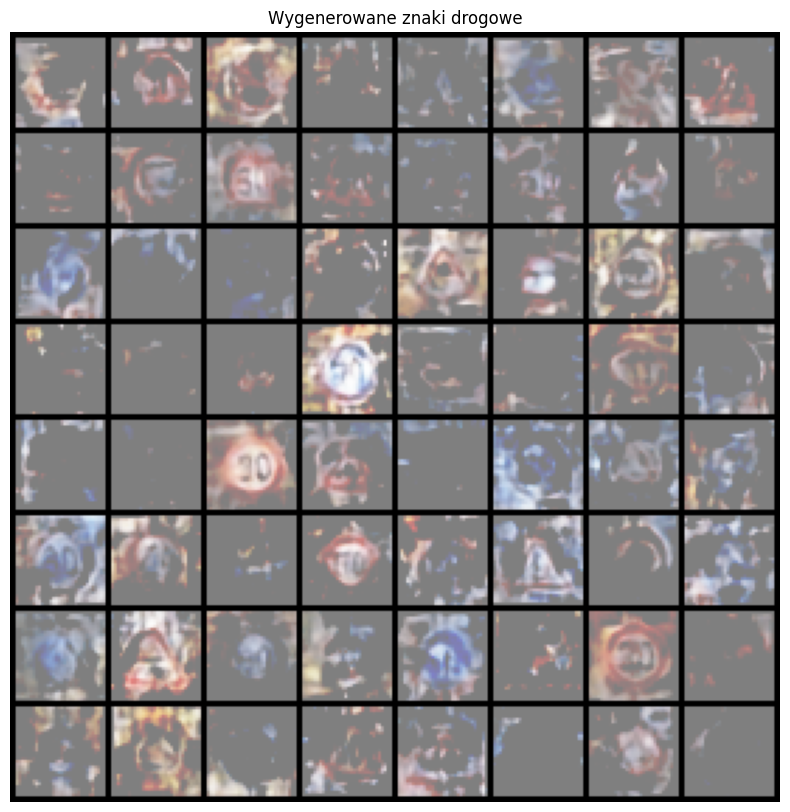

In [107]:
import matplotlib.pyplot as plt

samples = torch.load("mini_project_4/piatek_Biegacz_Cieslik/piatek_Biegacz_Cieslik.pt",     weights_only=True)

grid = torchvision.utils.make_grid(samples[:64], nrow=8)

plt.figure(figsize=(10, 10))
plt.imshow(grid.permute(1, 2, 0).numpy())
plt.title("Wygenerowane znaki drogowe")
plt.axis("off")
plt.show()